# Explore data and evaluate baseline models

This Notebook and its symbols will only be edited within the project folder and not through the website. To find specific symbols please edit SYMBOL = ""


This notebook loads stored market data, visualizes it, builds shared features, trains baseline models, and compares their performance.

The notebook expects to be run from the MLLSP project and never stores API keys.



In [ ]:
from pathlib import Path
import sys
from os import chdir

import matplotlib
matplotlib.use("Agg")  # non-interactive backend required when running via papermill
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

chdir(ROOT)
sys.path.insert(0, str(ROOT))
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Project root: {ROOT}")
print(f"Working directory: {Path.cwd()}")

Project root: c:\Users\Max\Desktop\MLLSP
Working directory: c:\Users\Max\Desktop\MLLSP


## 2. Load Project Configuration

Load local configuration without displaying secrets. API keys are not needed for this analysis notebook.

In [2]:
import os
from dotenv import dotenv_values

env_path = ROOT / "src" / "backend" / ".env"
config = dotenv_values(env_path) if env_path.exists() else {}
print(f"Environment file found: {env_path.exists()}")
print(f"Database configured: {bool(config.get('DATABASE_URL'))}")
print(f"API key configured: {bool(config.get('TWELVE_DATA_API_KEY'))}")

Environment file found: True
Database configured: True
API key configured: True


## 3. Inspect Project Files and Structure

Confirm the database and model directories before loading data.

In [3]:
for path in [ROOT / "src" / "backend" / "db", ROOT / "src" / "backend" / "features", ROOT / "src" / "backend" / "training"]:
    print(f"{path.relative_to(ROOT)}: {path.exists()}")

model_dir = ROOT / "src" / "backend" / "training" / "models"
print("\nTraining model files:")
for path in sorted(model_dir.glob("*")):
    print(f"- {path.name}")

src\backend\db: True
src\backend\features: True
src\backend\training: True

Training model files:
- AAPL_linear_regression.joblib
- AAPL_metadata.json
- latest.json


## 4. Clean and Prepare Data

Load AAPL observations from SQLite and normalize values for analysis.

In [ ]:
from src.backend.db import SessionLocal, init_db
from src.backend.db.models import MarketObservation, Symbol

#moddify symbol to load data for
SYMBOL = "TSLA"
init_db()
db = SessionLocal()
observations = (
    db.query(MarketObservation)
    .join(Symbol)
    .filter(Symbol.ticker == SYMBOL)
    .order_by(MarketObservation.timestamp)
    .all()
)

if not observations:
    db.close()
    raise ValueError(
        f"No observations found for {SYMBOL}. "
        "Import historical prices before running this notebook."
    )

data = pd.DataFrame([
    {
        "timestamp": observation.timestamp,
        "open": float(observation.open),
        "high": float(observation.high),
        "low": float(observation.low),
        "close": float(observation.close),
        "volume": float(observation.volume) if observation.volume is not None else None,
    }
    for observation in observations
])

data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")
for column in ["open", "high", "low", "close", "volume"]:
    data[column] = pd.to_numeric(data[column], errors="coerce")

data = data.dropna(subset=["timestamp", "close"]).sort_values("timestamp").reset_index(drop=True)
print(f"Loaded {len(data)} observations for {SYMBOL}")
data.head()

Loaded 31 observations for AAPL


,timestamp,open,high,low,close,volume
0,2026-07-06,307.35999,314.20001,307.000000,312.66000,53590000.0
1,2026-07-07,315.29001,315.48001,310.149990,310.66000,42490000.0
2,2026-07-08,311.91000,314.82001,307.049988,313.39001,41323500.0
3,2026-07-09,310.51001,316.53000,308.160000,316.22000,48124500.0
4,2026-07-10,314.72000,316.91000,312.170010,315.32001,34132300.0


## 5. Explore Project Metrics

Review summary statistics and simple market changes before training.

In [5]:
data.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
timestamp,31,2026-07-26 03:33:52.258064384,2026-07-06 00:00:00,2026-07-15 12:00:00,2026-07-27 00:00:00,2026-08-05 12:00:00,2026-08-14 14:30:00,NaN
open,31.0,317.151615,302.73001,307.554995,314.34,325.5,340.029999,11.333818
high,31.0,320.86355,305.66,311.199995,316.29001,331.655,344.57001,11.942293
low,31.0,314.253871,300.0,305.14,310.73999,322.78,337.35001,11.302203
close,31.0,318.368386,302.25,309.145,314.85999,327.619995,340.079987,11.677967
volume,30.0,51296536.666667,28186700.0,40961475.0,46814650.0,55465600.0,132489100.0,19338842.542843


In [6]:
returns = data["close"].pct_change()
print(f"Date range: {data['timestamp'].min()} to {data['timestamp'].max()}")
print(f"Closing price change: {data['close'].iloc[0]:.2f} -> {data['close'].iloc[-1]:.2f}")
print(f"Missing values:\n{data.isna().sum()}")
print(f"Average daily return: {returns.mean():.4f}")

Date range: 2026-07-06 00:00:00 to 2026-08-14 14:30:00
Closing price change: 312.66 -> 305.93
Missing values:
timestamp    0
open         0
high         0
low          0
close        0
volume       1
dtype: int64
Average daily return: -0.0005


## 6. Build Reusable Helper Functions

Use the same feature-engineering implementation as the training pipeline.

In [7]:
from src.backend.features import FEATURE_COLUMNS, build_feature_frame

def plot_series(frame, columns, title, ylabel):
    frame.plot(x="timestamp", y=columns, figsize=(12, 5), title=title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

feature_frame = build_feature_frame(data)
feature_frame.head()

,timestamp,return_1,close_lag_1,close_lag_5,volatility_5,target_close
5,2026-07-13,0.006311,315.32001,312.66000,0.007129,314.85999
6,2026-07-14,-0.007721,317.31000,310.66000,0.007575,327.50000
7,2026-07-15,0.040145,314.85999,313.39001,0.018689,333.26001
8,2026-07-16,0.017588,327.50000,316.22000,0.019082,333.73999
9,2026-07-17,0.001440,333.26001,315.32001,0.018406,326.59000




The model uses historical closing prices to predict the **next closing price**.

The shared feature function creates four inputs for each usable row:

- `return_1`: the percentage change from the previous close.
- `close_lag_1`: the previous closing price.
- `close_lag_5`: the closing price five observations earlier.
- `volatility_5`: the rolling standard deviation of the last five returns.

The target is `target_close`, which is the next observation's closing price. The model currently uses only `close`; the stored open, high, low, and volume columns are displayed but are not training inputs.

With 31 observations, the first five rows are needed to calculate lagged and rolling features, and the final row has no future target. This leaves 25 usable samples.

## 7. Generate Visualizations

Plot prices, volume, engineered features, and model error comparisons.

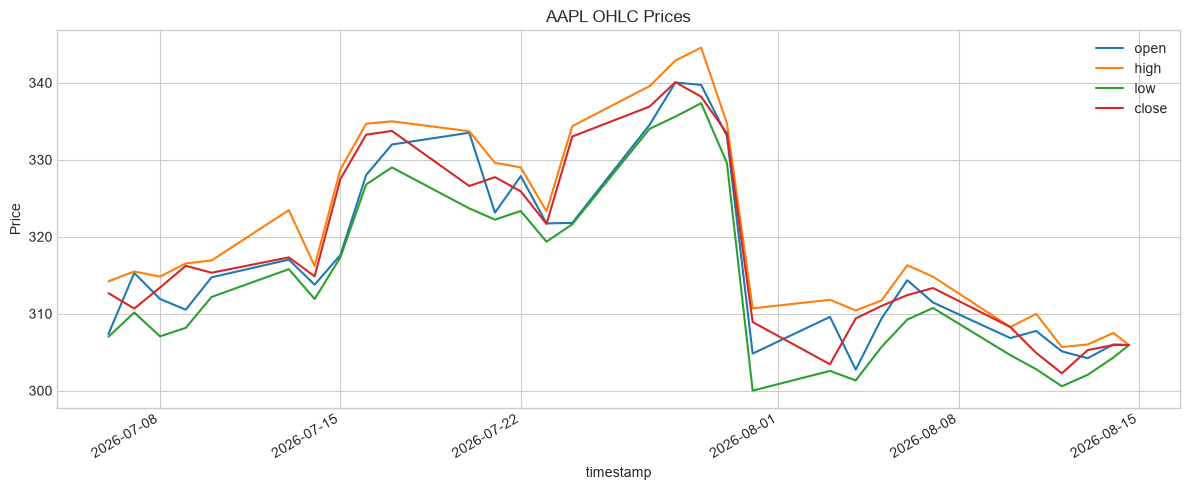

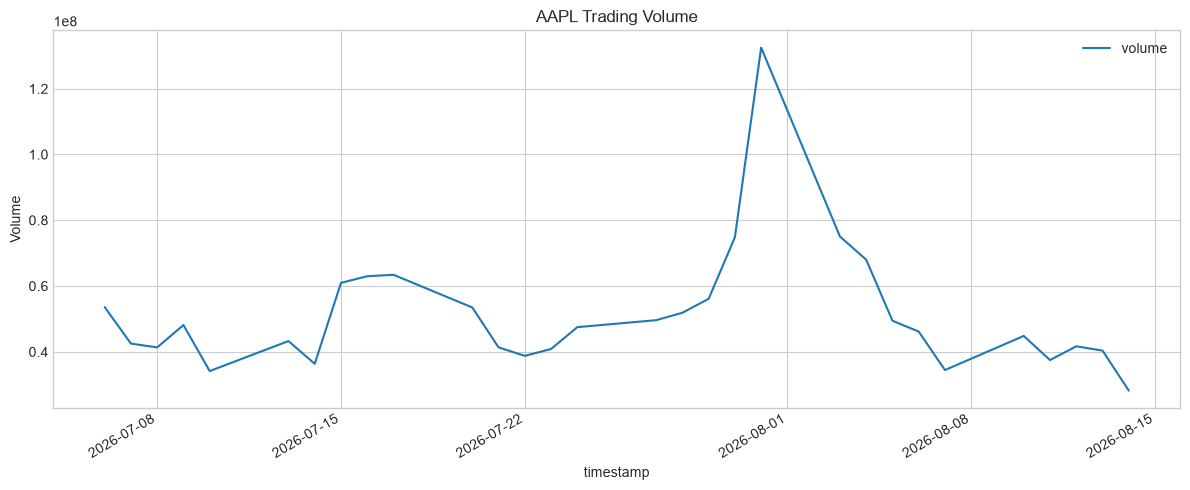

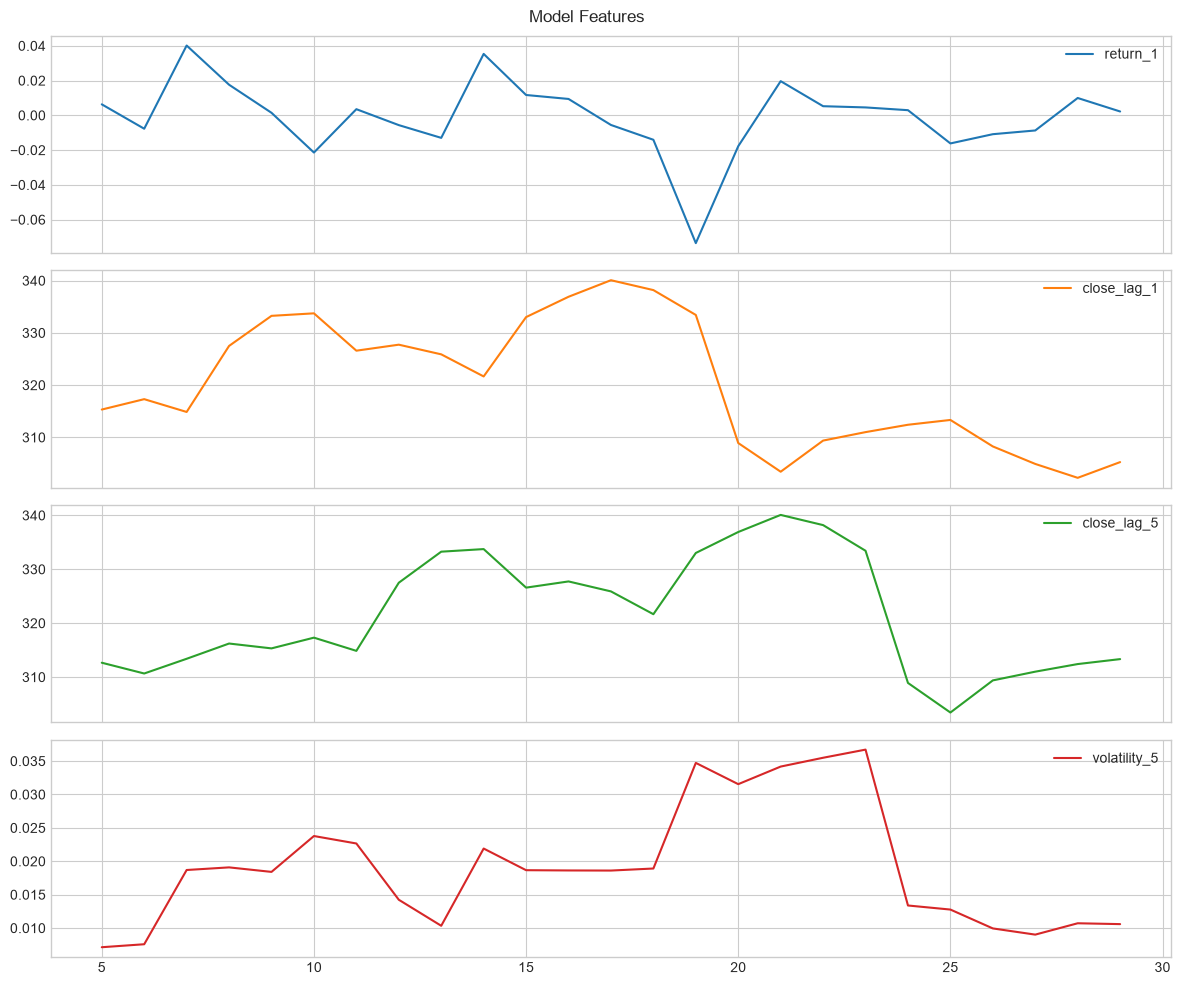

In [8]:
plot_series(data, ["open", "high", "low", "close"], f"{SYMBOL} OHLC Prices", "Price")

if data["volume"].notna().any():
    plot_series(data, ["volume"], f"{SYMBOL} Trading Volume", "Volume")

feature_frame[FEATURE_COLUMNS].plot(subplots=True, figsize=(12, 10), title="Model Features")
plt.tight_layout()
plt.show()

In [9]:
from src.backend.training import train_symbol

result = train_symbol(db, SYMBOL)
metrics = pd.DataFrame(result.metrics).T
print(f"Best trained model: {result.best_model}")
print(f"Samples used: {result.sample_count}")
print(f"Saved model: {result.model_path}")
metrics

Best trained model: linear_regression
Samples used: 25
Saved model: C:\Users\Max\Desktop\MLLSP\src\backend\training\models\AAPL_linear_regression.joblib


,mae,rmse,r2
linear_regression,5.794736,6.047355,-18.737357
random_forest,11.609064,11.868258,-75.020734
gradient_boosting,7.673091,9.092088,-43.615457
naive_previous_close,3.825996,4.921995,-12.074960


## How the models are evaluated

The data is kept in time order. The first 80% of the usable rows trains each model, and the final 20% tests it on later data. The data is not shuffled because using future prices to train a past prediction would create leakage.

Three baseline regressors are compared:

- Linear Regression
- Random Forest
- Gradient Boosting

The notebook also tests a simple naive baseline: predict the next close as the current close. This baseline is important because a trained model should beat a simple rule before it is considered useful.

The metrics are:

- **MAE:** average absolute prediction error.
- **RMSE:** prediction error that penalizes larger mistakes more strongly.
- **R²:** how much variation the model explains relative to a simple average prediction.

The best saved model is selected from the three trained regressors by the lowest RMSE. The naive baseline is reported for comparison but is not currently eligible to be saved as the best model.

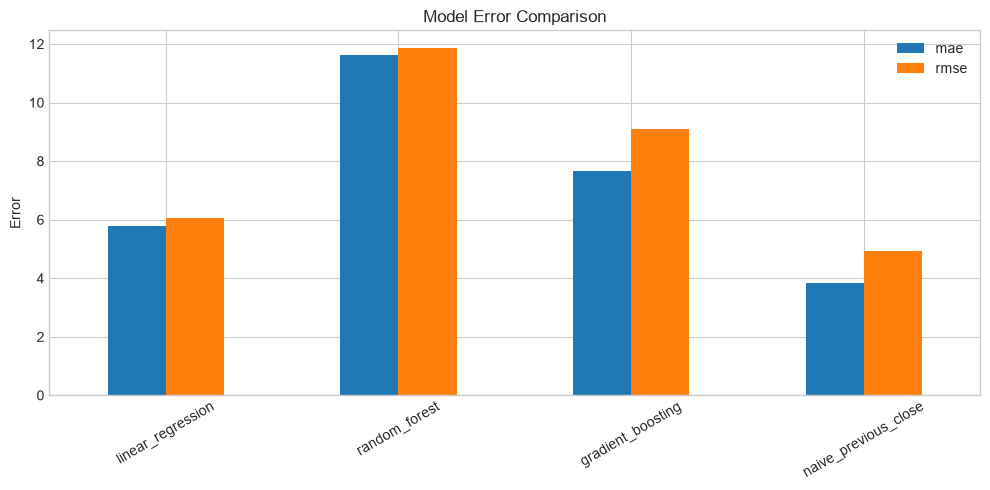

In [10]:
metrics[["mae", "rmse"]].plot(kind="bar", figsize=(10, 5), title="Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Validate Results

Check that the data, features, model artifact, and metadata are present.

In [11]:
assert not data.empty, "No market data was loaded"
assert set(FEATURE_COLUMNS).issubset(feature_frame.columns)
assert result.model_path.exists(), "The trained model was not saved"
assert (ROOT / "src" / "backend" / "training" / "models" / f"{SYMBOL}_metadata.json").exists()

best_regressor_rmse = metrics.drop(index="naive_previous_close")["rmse"].min()
naive_rmse = metrics.loc["naive_previous_close", "rmse"]
print("Validation passed: data, features, model artifact, and metadata are present.")
print(f"Naive baseline RMSE: {naive_rmse:.4f}")
print(f"Best regressor RMSE: {best_regressor_rmse:.4f}")
if naive_rmse < best_regressor_rmse:
    print("Note: the naive baseline currently outperforms the regressors; collect more data before drawing conclusions.")

Validation passed: data, features, model artifact, and metadata are present.
Naive baseline RMSE: 4.9220
Best regressor RMSE: 6.0474
Note: the naive baseline currently outperforms the regressors; collect more data before drawing conclusions.


## 9. Export Processed Outputs

Save cleaned data, features, and metrics so they can be reviewed outside the notebook.

In [12]:
output_dir = ROOT / "docs" / "notebooks" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)
data.to_csv(output_dir / f"{SYMBOL}_cleaned_prices.csv", index=False)
feature_frame.to_csv(output_dir / f"{SYMBOL}_features.csv", index=False)
metrics.to_csv(output_dir / f"{SYMBOL}_model_metrics.csv")

print(f"Exported outputs to {output_dir.relative_to(ROOT)}")

Exported outputs to docs\notebooks\outputs


In [13]:
db.close()
print("Database session closed.")

Database session closed.
